# Merge figures

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams.update({"font.family":"serif","font.serif":["DejaVu Serif"],"font.weight":"normal","axes.titleweight":"normal","figure.titleweight":"normal","mathtext.fontset":"dejavuserif"})

import os, sys
sys.path.insert(0, os.path.abspath("../../.."))    # repository root, for vmatplot
from vmatplot.output_settings import figure_version, save_figure

figure_version("article")    # "thesis": panel labels 1.2x larger, figures saved as figures/<name>_thesis.pdf

def _offset(cell,obj,mode):
    if mode=="left" or mode=="top": return 0
    if mode=="right" or mode=="bottom": return cell-obj
    return (cell-obj)//2

def _merge_rasters(image_paths,ncol,nrow,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"):
    annotate_color="#000"; paths=[]; labels=[]
    for item in image_paths:
        if isinstance(item,(list,tuple)): paths.append(item[0]); labels.append(item[1] if len(item)>1 else None)
        else: paths.append(item); labels.append(None)
    if len(paths)!=ncol*nrow: raise ValueError(f"This function requires exactly {ncol*nrow} images.")
    images=[Image.open(path).convert("RGB") for path in paths]
    width,height=max(img.size[0] for img in images),max(img.size[1] for img in images)
    if label_fontsize is None: label_fontsize=(1.2 if figure_version()=="thesis" else 1)*max(14,int(min(width,height)*0.03))
    if label_pad is None: label_pad=((width+height)/50,(width+height)/50)
    result_width,result_height=ncol*width,nrow*height
    result=Image.new("RGB",(result_width,result_height),(255,255,255))
    placements=[(row+col*nrow,col,row) for row in range(nrow) for col in range(ncol)]
    for i,col,row in placements:
        img=images[i]; w_img,h_img=img.size; x,y=col*width+_offset(width,w_img,halign),row*height+_offset(height,h_img,valign)
        result.paste(img,(x,y))
    fig,ax=plt.subplots(figsize=(result_width/dpi,result_height/dpi),dpi=dpi)
    ax.imshow(result,interpolation="none"); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    if divider:
        for y in [k*height-0.5 for k in range(1,nrow)]: ax.axhline(y=y,color=line_color,linewidth=divider_linewidth,zorder=3)
        for x in [k*width-0.5 for k in range(1,ncol)]: ax.axvline(x=x,color=line_color,linewidth=divider_linewidth,zorder=3)
    if border: ax.add_patch(Rectangle((-0.5,-0.5),result_width,result_height,fill=False,edgecolor=line_color,linewidth=border_linewidth,clip_on=False,zorder=4))
    pad_x,pad_y=label_pad; bbox_style=dict(boxstyle="round,pad=0.4",facecolor="white",edgecolor="#808080",linewidth=6,alpha=0.8)
    for i,col,row in placements:
        label=labels[i]
        if label is None or str(label).strip()=="": continue
        img=images[i]; w_img,h_img=img.size
        x=col*width+_offset(width,w_img,halign)+pad_x; y=row*height+_offset(height,h_img,valign)+pad_y
        ax.text(x,y,str(label),color=annotate_color,fontsize=label_fontsize,ha="left",va="top",fontweight="normal",bbox=bbox_style,wrap=True,zorder=5)
    if suptitle: fig.suptitle(suptitle,fontsize=20,y=0.98,fontweight="normal"); fig.subplots_adjust(left=0,right=1,bottom=0,top=0.94)
    else: fig.subplots_adjust(left=0,right=1,bottom=0,top=1)
    # plt.show()

def merge_2_rasters_hor(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,2,1,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_2_rasters_ver(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,1,2,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_3_rasters_hor(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,3,1,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_3_rasters_ver(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,1,3,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_4_rasters(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,2,2,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_6_rasters(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,3,2,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_9_rasters(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,3,3,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)

def save_merged(name):
    # figures/<name>.pdf (article) or figures/<name>_thesis.pdf; the inline preview is drawn about 1600 px wide
    save_figure(name, directory="../..")
    plt.gcf().set_dpi(1600/plt.gcf().get_size_inches()[0])

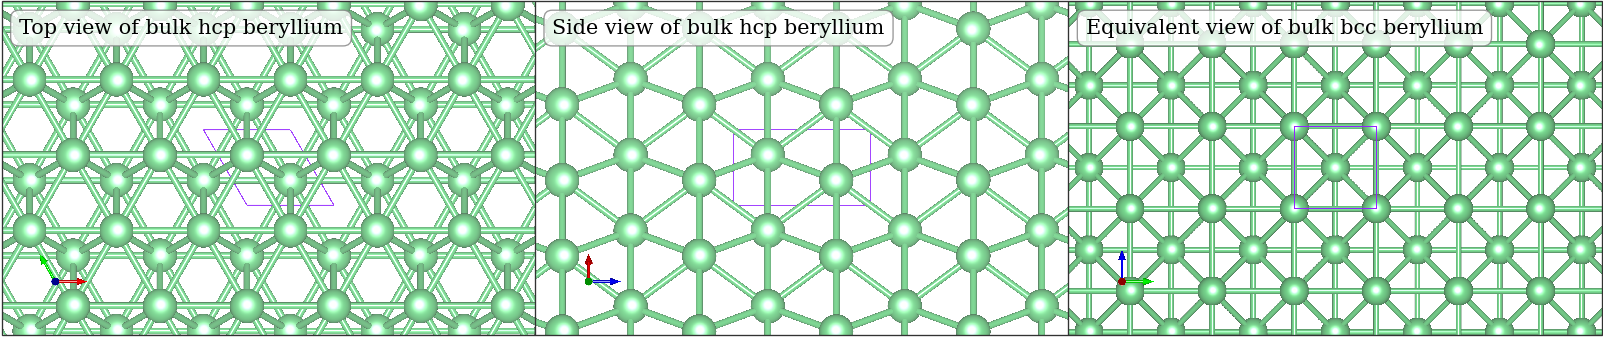

In [2]:
# fig 1 bulks views

merge_3_rasters_hor([
    ["1a_a-beryllium_top.png","Top view of bulk hcp beryllium"],
    ["1a_a-beryllium_side.png","Side view of bulk hcp beryllium"],
    ["1b_c-beryllium_demo_top.png","Equivalent view of bulk bcc beryllium"]
])

save_merged("structure_bulk")

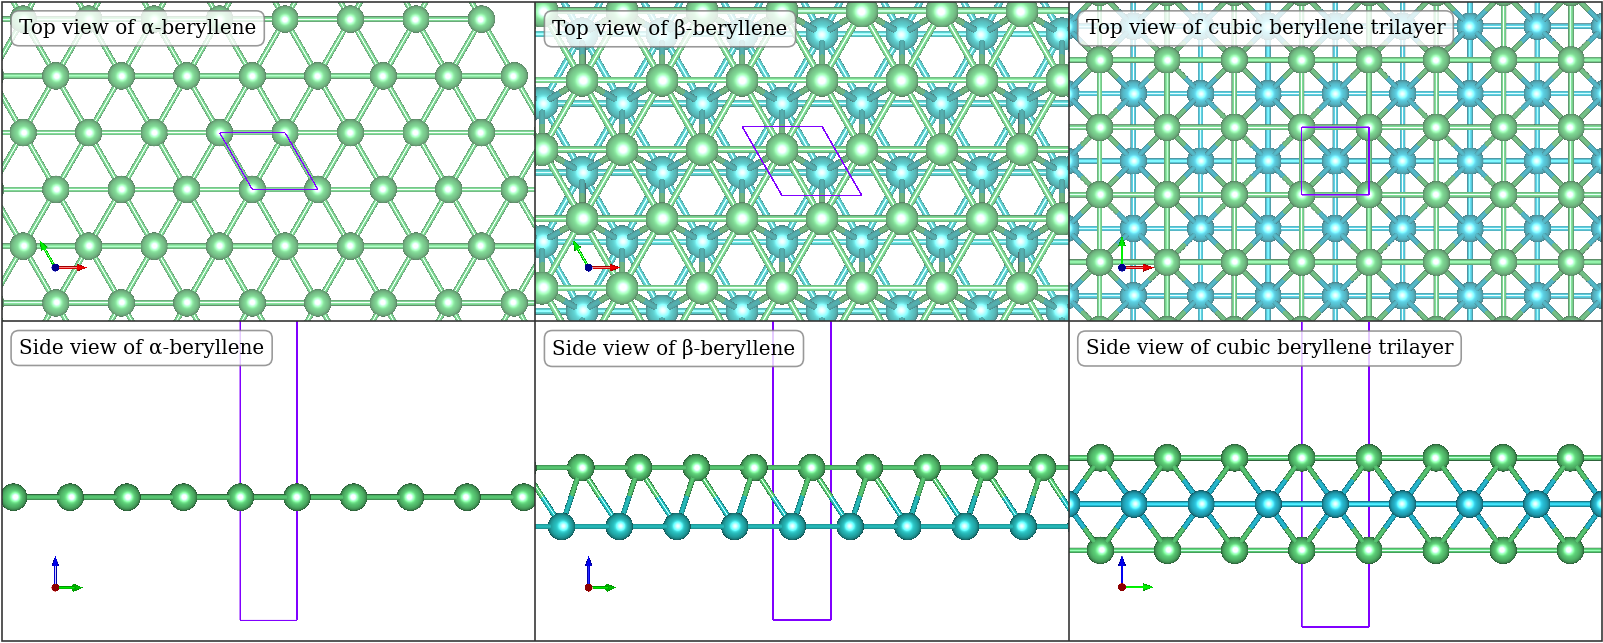

In [3]:
# fig 2 layers views

merge_6_rasters([
    ["2a_a-beryllene_top.png","Top view of α-beryllene"],
    ["2a_a-beryllene_side.png","Side view of α-beryllene"],
    ["2b_b-beryllene_top.png","Top view of β-beryllene"],
    ["2b_b-beryllene_side.png","Side view of β-beryllene"],
    ["2c_c-beryllene_trilayer_top.png","Top view of cubic beryllene trilayer"],
    ["2c_c-beryllene_trilayer_side.png","Side view of cubic beryllene trilayer"],
])

save_merged("structure_pristine")

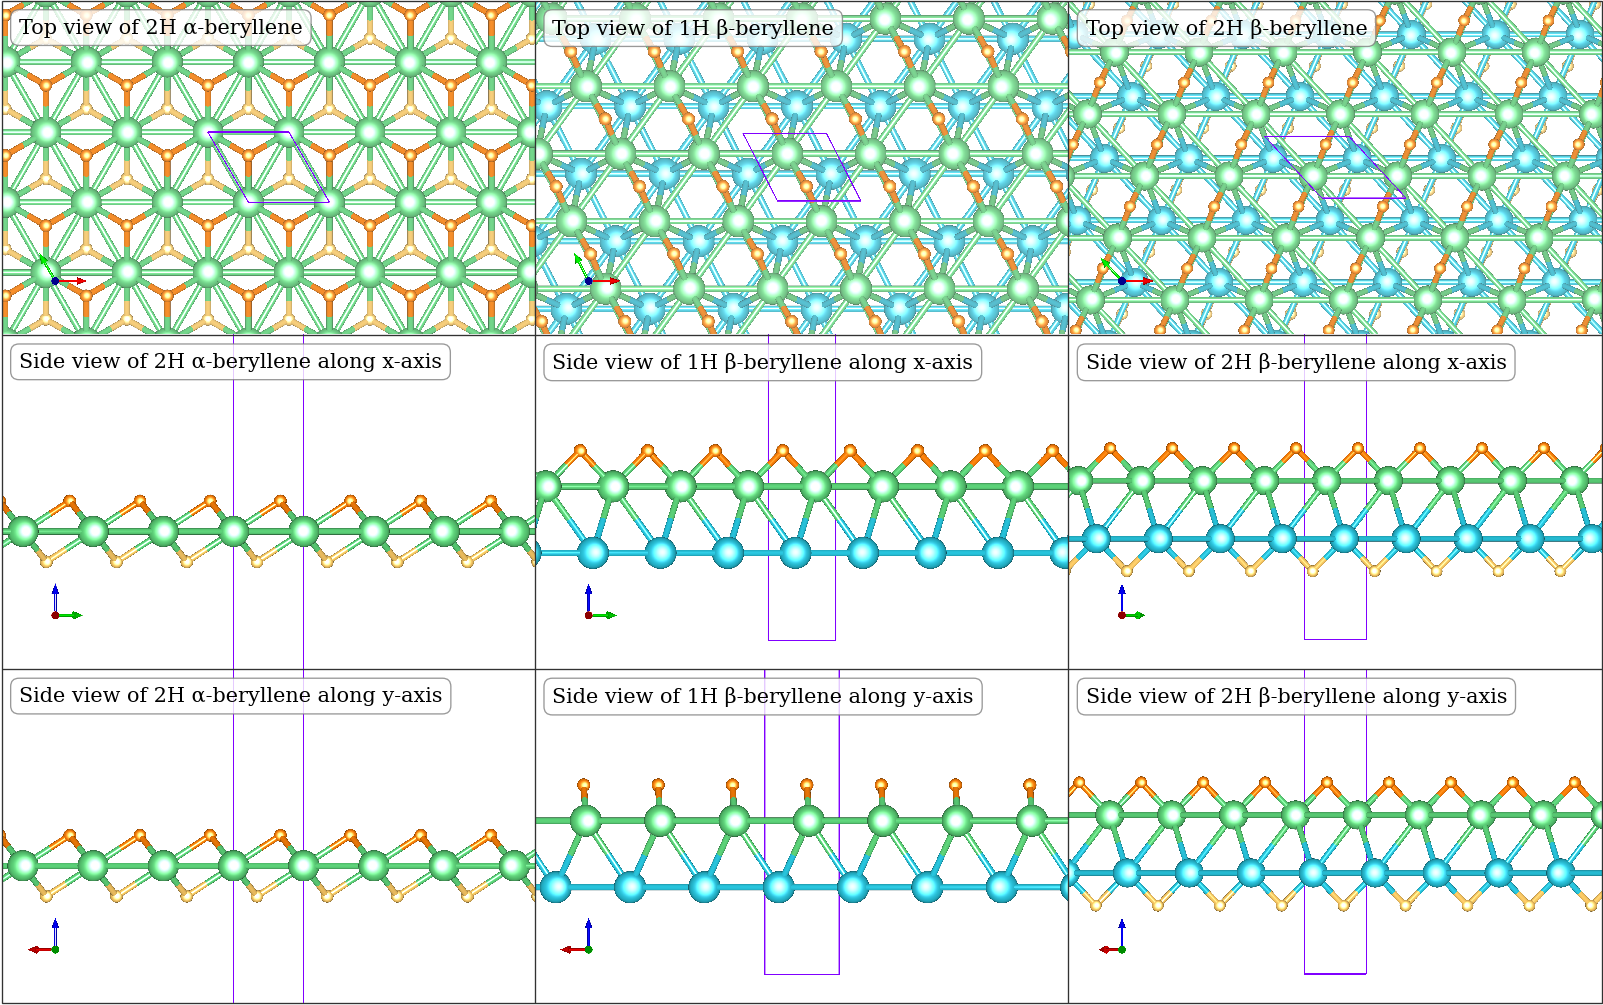

In [4]:
# fig 3 H-termined layers views

merge_9_rasters([
    ["3a_a-beryllene_hh_top.png","Top view of 2H α-beryllene"],
    ["3a_a-beryllene_hh_x.png","Side view of 2H α-beryllene along x-axis"],
    ["3a_a-beryllene_hh_y.png","Side view of 2H α-beryllene along y-axis"],
    ["3b_b-beryllene_b_top.png","Top view of 1H β-beryllene"],
    ["3b_b-beryllene_b_x.png","Side view of 1H β-beryllene along x-axis"],
    ["3b_b-beryllene_b_y.png","Side view of 1H β-beryllene along y-axis"],
    ["3c_b-beryllene_bb_top.png","Top view of 2H β-beryllene"],
    ["3c_b-beryllene_bb_x.png","Side view of 2H β-beryllene along x-axis"],
    ["3c_b-beryllene_bb_y.png","Side view of 2H β-beryllene along y-axis"],
])

save_merged("structure_hydrogenated")